# Statistical Analysis

Para este notebook se neceista el siguiente dataset: panel_BALANCED_MAIN_MarJun_2020_2024_2025_AB_v1.csv

C:\Users\Val\AppData\Local\Temp\ipykernel_3940\2590980762.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min().floor("H"), g["date"].max().ceil("H"), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_3940\2590980762.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min().floor("H"), g["date"].max().ceil("H"), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_3940\2590980762.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min().floor("H"), g["date"].max().ceil("H"), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_3940\2590980762.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min().floor("H"), g["date"].max().ceil("H"), freq="H")


Guardado: ..\data\processed\CO_max8h_daily_city_MAIN_MarJun_2020_2024_2025.csv


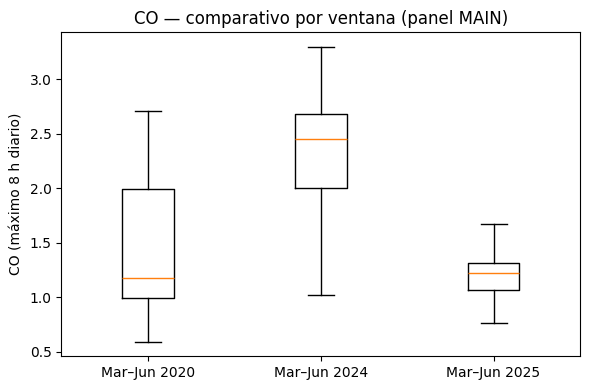

In [1]:
# Comparación de CO (máximo móvil 8h diario) entre Mar–Jun 2020, 2024 y 2025 — panel MAIN
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.path.join("..","data","processed")
IN_FILE  = os.path.join(DATA_DIR, "panel_BALANCED_MAIN_MarJun_2020_2024_2025_AB_v1.csv")

main = pd.read_csv(IN_FILE, parse_dates=["date"], engine="pyarrow")

# Nos quedamos con CO y filas no vacías
co = main.loc[main["CO"].notna(), ["date","station_code","period_window","CO"]].copy()

def daily_max8h_for_group(g):
    # Reindex a grilla horaria para rolling robusto
    idx = pd.date_range(g["date"].min().floor("H"), g["date"].max().ceil("H"), freq="H")
    s = g.set_index("date")["CO"].reindex(idx)
    # Promedio móvil de 8h (permitimos algunos NaN)
    m8 = s.rolling(window=8, min_periods=6).mean()
    # Máximo diario
    dmax = m8.resample("D").max()
    out = dmax.to_frame("co_max8h").reset_index().rename(columns={"index":"day"})
    out["station_code"] = g["station_code"].iat[0]
    out["period_window"] = g["period_window"].iat[0]
    return out

# 1) Máximo 8h diario por estación y ventana
by_sta = (co.sort_values("date")
            .groupby(["period_window","station_code"], group_keys=False)
            .apply(daily_max8h_for_group))

# 2) Serie “ciudad”: promedio entre estaciones por día (igual peso)
city_daily = (by_sta.groupby(["period_window","day"])["co_max8h"]
                   .mean()
                   .reset_index())

# 3) Guardar tabla (útil para el reporte)
out_tbl = os.path.join(DATA_DIR, "CO_max8h_daily_city_MAIN_MarJun_2020_2024_2025.csv")
city_daily.to_csv(out_tbl, index=False)
print("Guardado:", out_tbl)

# 4) Boxplot comparativo por ventana
order = ["pandemic_MarJun2020","baseline_MarJun2024","current_MarJun2025"]
data = [city_daily.loc[city_daily["period_window"]==w, "co_max8h"].dropna().values for w in order]

plt.figure(figsize=(6,4))
plt.boxplot(data, labels=["Mar–Jun 2020","Mar–Jun 2024","Mar–Jun 2025"], showfliers=False)
plt.ylabel("CO (máximo 8 h diario)")
plt.title("CO — comparativo por ventana (panel MAIN)")
plt.tight_layout()
plt.show()


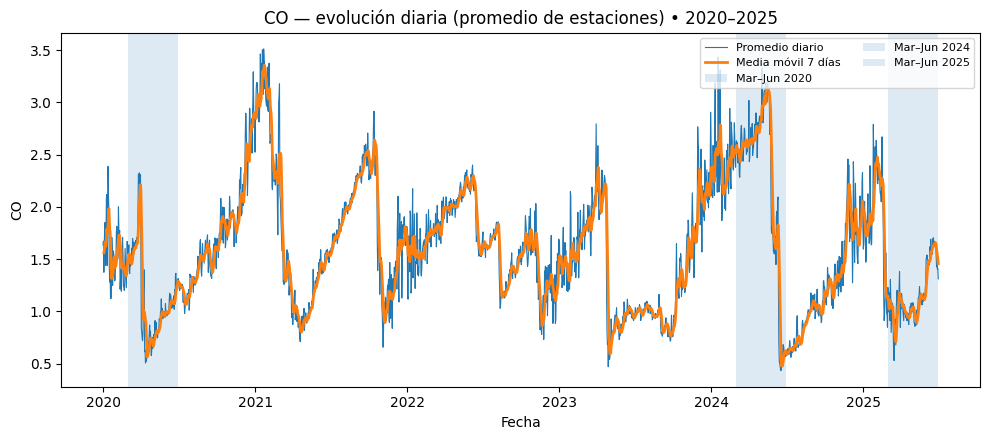

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Carga (ajusta la ruta a tu proyecto)
df = pd.read_csv("../data/processed/pre_imputation_subset_AB_v1.csv",
                 parse_dates=["date"], engine="pyarrow")

# 2) Promedio diario de CO (promedia entre estaciones cada día)
co_daily = (df.dropna(subset=["CO"])
              .assign(day=lambda x: x["date"].dt.floor("D"))
              .groupby("day")["CO"].mean()
              .to_frame("CO_diario"))
co_daily["CO_7d"] = co_daily["CO_diario"].rolling(7, min_periods=3).mean()

# 3) Ventanas a resaltar (Mar–Jun 2020, 2024 y 2025)
windows = [
    ("2020-03-01","2020-06-30","Mar–Jun 2020"),
    ("2024-03-01","2024-06-30","Mar–Jun 2024"),
    ("2025-03-01","2025-06-30","Mar–Jun 2025"),
]

# 4) Gráfico (una sola figura, sin estilos especiales)
plt.figure(figsize=(10,4.5))
plt.plot(co_daily.index, co_daily["CO_diario"], linewidth=0.8, label="Promedio diario")
plt.plot(co_daily.index, co_daily["CO_7d"], linewidth=2.0, label="Media móvil 7 días")

for start, end, label in windows:
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, label=label)

plt.title("CO — evolución diaria (promedio de estaciones) • 2020–2025")
plt.xlabel("Fecha")
plt.ylabel("CO")
plt.legend(loc="upper right", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


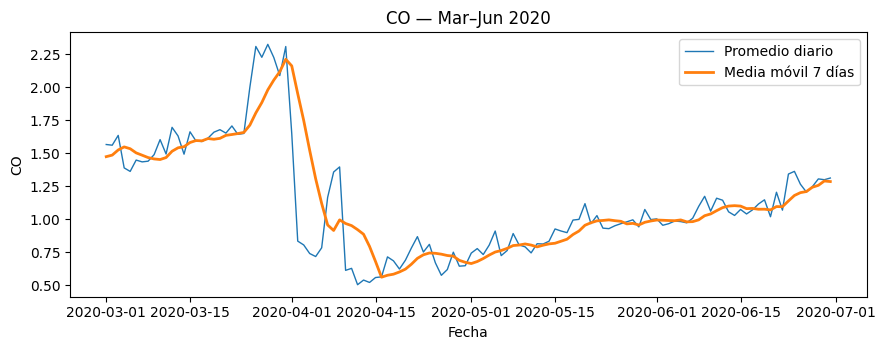

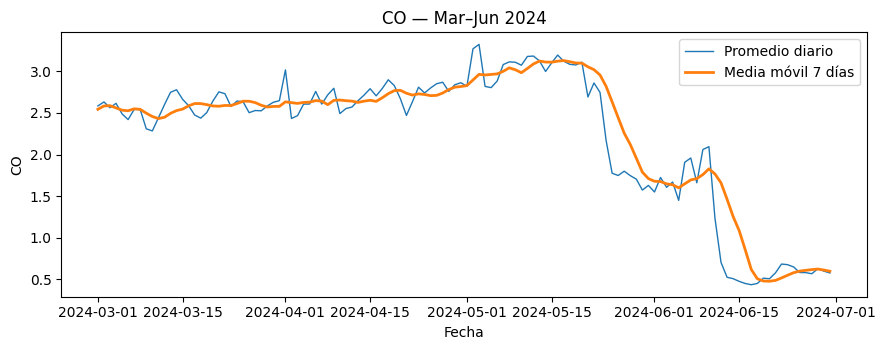

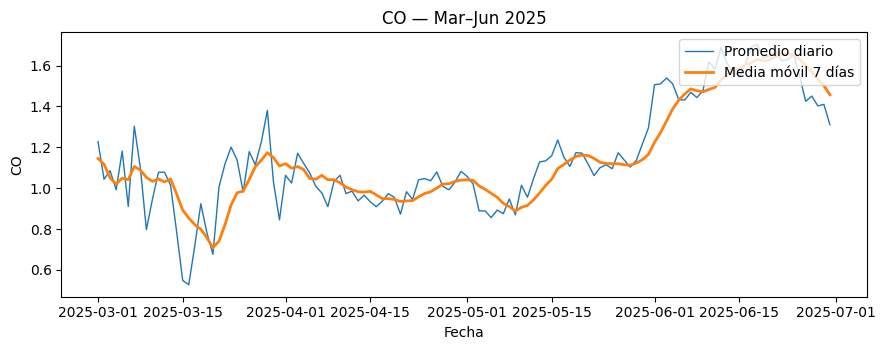

In [4]:

# Carga (ajusta si tu ruta difiere)
df = pd.read_csv("../data/processed/pre_imputation_subset_AB_v1.csv",
                 parse_dates=["date"], engine="pyarrow")

# Promedio diario entre estaciones
co_daily = (df.dropna(subset=["CO"])
              .assign(day=lambda x: x["date"].dt.floor("D"))
              .groupby("day")["CO"].mean()
              .to_frame("CO_diario"))
co_daily["CO_7d"] = co_daily["CO_diario"].rolling(7, min_periods=3).mean()

# Ventanas a graficar por separado
windows = [
    ("2020-03-01","2020-06-30","CO — Mar–Jun 2020"),
    ("2024-03-01","2024-06-30","CO — Mar–Jun 2024"),
    ("2025-03-01","2025-06-30","CO — Mar–Jun 2025"),
]

for start, end, title in windows:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    # Reindex a rejilla diaria continua dentro de la ventana (para ver huecos si los hay)
    idx = pd.date_range(s, e, freq="D")
    sub = (co_daily.reindex(idx)
                  .rename_axis("day")
                  .reset_index())

    plt.figure(figsize=(9,3.6))
    plt.plot(sub["day"], sub["CO_diario"], linewidth=1.0, label="Promedio diario")
    plt.plot(sub["day"], sub["CO_7d"], linewidth=2.0, label="Media móvil 7 días")
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("CO")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
